In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct

import funciones_aux as fau

import funciones_dsa as fun_dsa
import funciones_dsa_unilateral as fun_dsa_u
import funciones_dsa_bilateral as fun_dsa_b

import funciones_plot_dsa as fun_plot

from scipy.signal import welch
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.stats import pearsonr, spearmanr


# OG

#### Archivo f_a

In [2]:
ruta_base_advanced = "../data/data_bis_advanced"

archivos_fa = fau.localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a
Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz


#### Archivo spa

In [3]:
ruta_spa_unilat = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
df_spa_unilat = fau.procesar_spa(ruta_spa_unilat)

## Unión de los 2

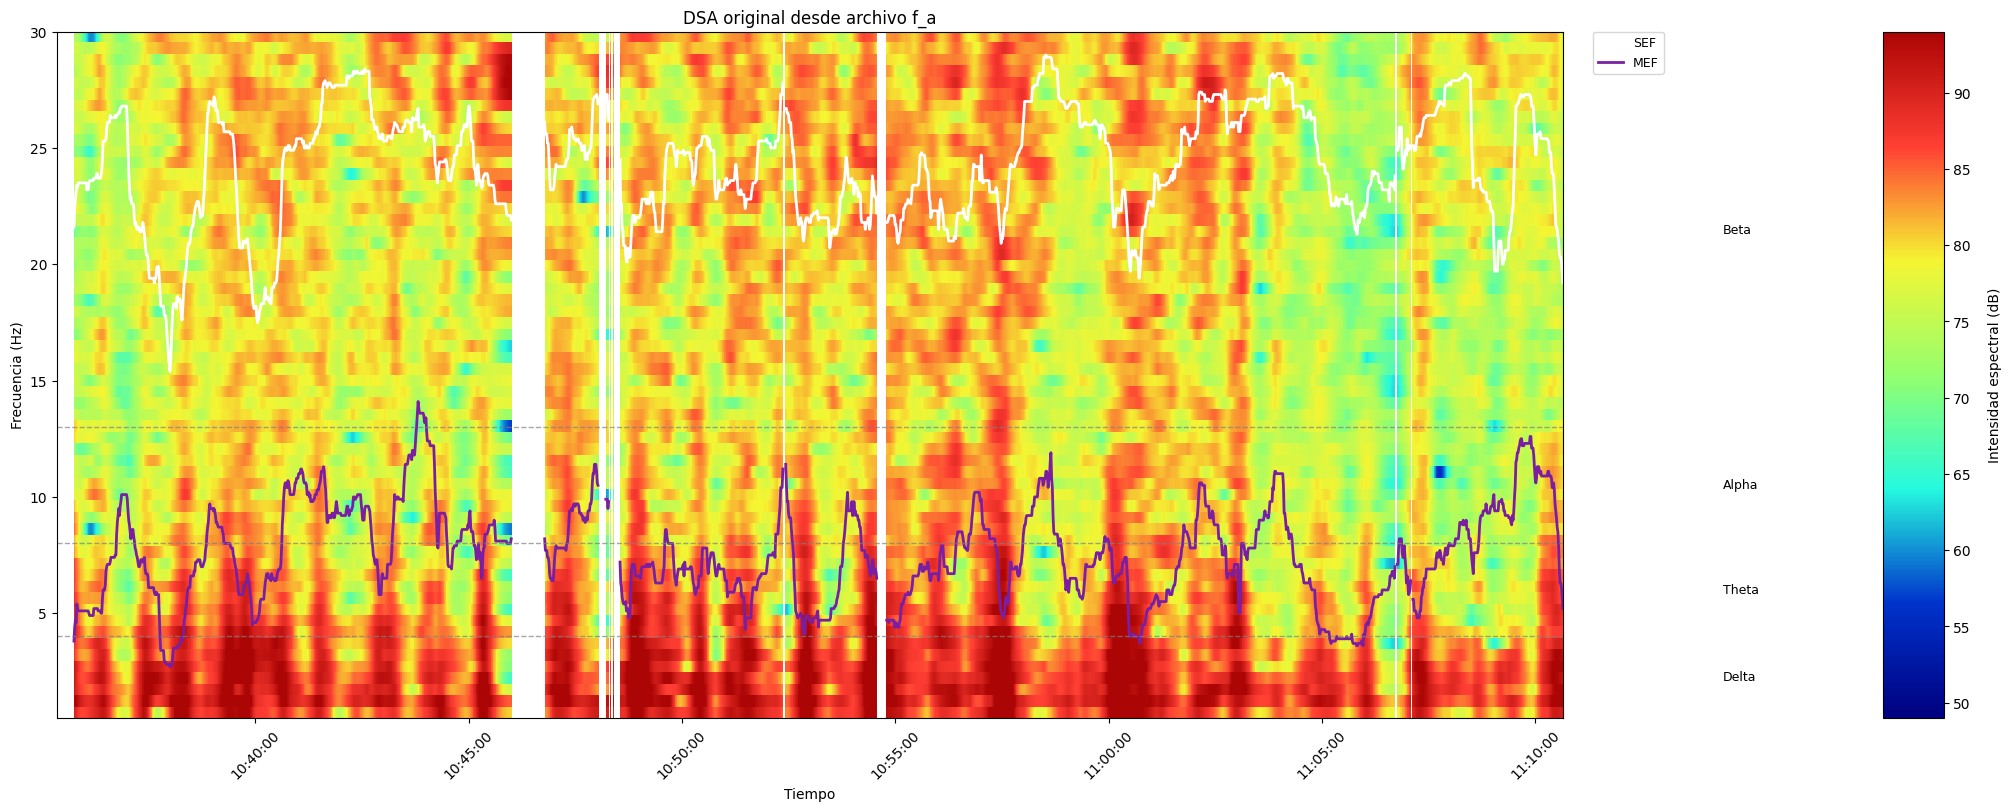

In [4]:
df_merge_hor = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_hor["SEF08"]
mf_hor = df_merge_hor["MEDFRQ08"]

dsa_plot_hor, mask_total_hor = fun_dsa.preparar_dsa_para_plot(tiempo_fa_unilat, dsa_unilat, df_merge_hor)
matriz_hor, vmin_hor, vmax_hor, norm_hor, cmap_hor = fun_dsa.preparar_escala_color_dsa(dsa_plot_hor, vmin=49, vmax=94, gamma=1)

fig, ax, ax_band, cax = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_fa_unilat,
    frecuencias=dsa_plot_hor.columns.astype(float),
    matriz=matriz_hor,
    norm=norm_hor,
    cmap=cmap_hor,
    df_merge=df_merge_hor,
    titulo="DSA original desde archivo f_a",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_total_hor
)

In [5]:
cols_freq = [c for c in dsa_plot_hor.columns]


print(np.nanmin(dsa_plot_hor[cols_freq].values))
print(np.nanmax(dsa_plot_hor[cols_freq].values))

print(np.nanpercentile(dsa_plot_hor[cols_freq].values, 2))
print(np.nanpercentile(dsa_plot_hor[cols_freq].values, 99.5))

55.61
103.02
69.81
96.86205000000002


# Procesado

In [6]:
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

### Reconstrucción desde EEG crudo

In [7]:
df_eeg = fun_dsa_u.leer_r2a(
    archivo_r2a,
    fs=128,
    escala_uv=0.0511
)

df_dsa_canal1, frecuencias = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    "canal_1_uV",
    fs=128,
    ventana_seg=2,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

df_dsa_canal2, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    "canal_2_uV",
    fs=128,
    ventana_seg=2,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="densidad",
    tiempo_referencia="centro"
)

cols_freq = [c for c in df_dsa_canal1.columns if c != "tiempo_s"]

df_dsa_media = df_dsa_canal1.copy()

pot_media = (
    df_dsa_canal1[cols_freq].to_numpy(dtype=float) +
    df_dsa_canal2[cols_freq].to_numpy(dtype=float)
) / 2

dsa_rec_db_simple = 10 * np.log10(pot_media + 1e-12)


# Conversión a dB usando la referencia documentada de la DSA BIS:
# 0.0001 µV RMS
ref_uv_rms = 0.0001

df_dsa_media[cols_freq] = 10 * np.log10(
    (pot_media + 1e-12) / (ref_uv_rms ** 2)
)

In [8]:
print(np.nanmin(df_dsa_media[cols_freq].values))
print(np.nanmax(df_dsa_media[cols_freq].values))

print(np.nanpercentile(df_dsa_media[cols_freq].values, 2))
print(np.nanpercentile(df_dsa_media[cols_freq].values, 99.5))

43.8952330105952
134.55921182485093
73.38077366240869
117.33046386583177


### Adaptación temporal, máscara y plot de DSA EEG

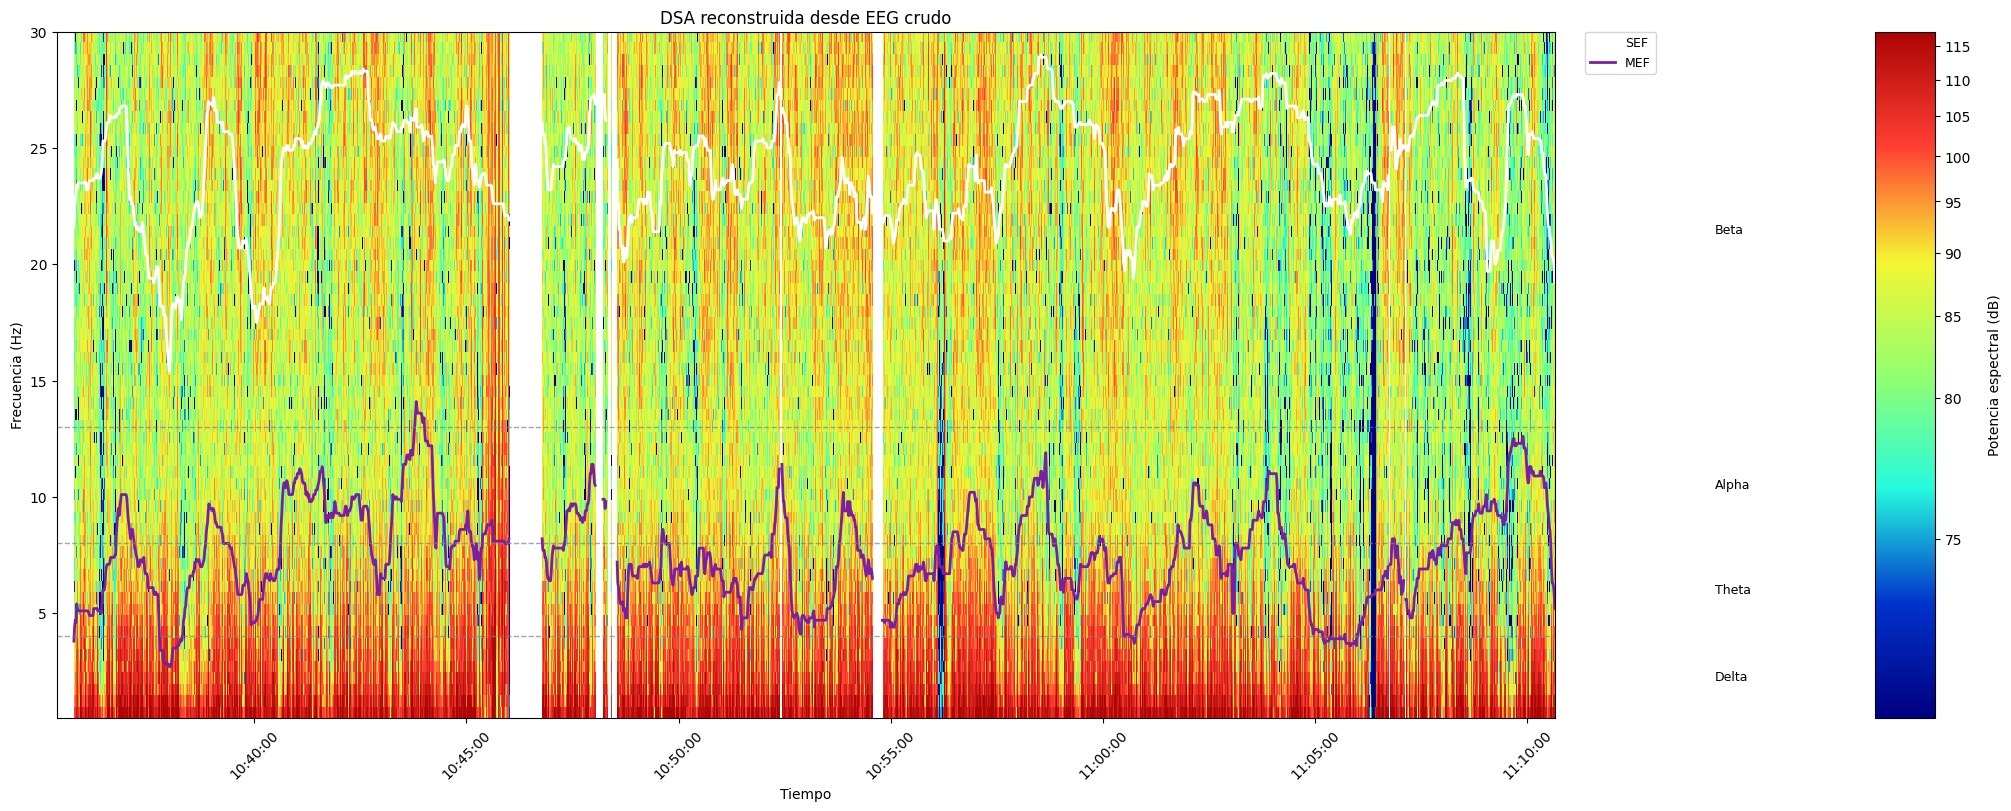

In [9]:
df_spa_unilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(
    df_spa_unilat
)

tiempo_eeg, dsa_eeg = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_media,
    frecuencias=frecuencias,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=True
)

df_merge_plot = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg,
    df_spa=df_spa_unilat
)

dsa_eeg_plot, mask_total = fun_dsa.preparar_dsa_para_plot(
    tiempo=tiempo_eeg,
    dsa=dsa_eeg,
    df_merge=df_merge_plot,
    umbral_sqi=14,
    umbral_ceros=0.9
)

matriz_eeg, vmin_eeg, vmax_eeg, norm_eeg, cmap_eeg =fun_dsa.preparar_escala_color_dsa(dsa_eeg_plot, gamma=0.4)

fig, ax, ax_band, cax = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg,
    frecuencias=frecuencias,
    matriz=matriz_eeg,
    norm=norm_eeg,
    cmap=cmap_eeg,
    df_merge=df_merge_plot,
    titulo="DSA reconstruida desde EEG crudo",
    mask_total=mask_total
)

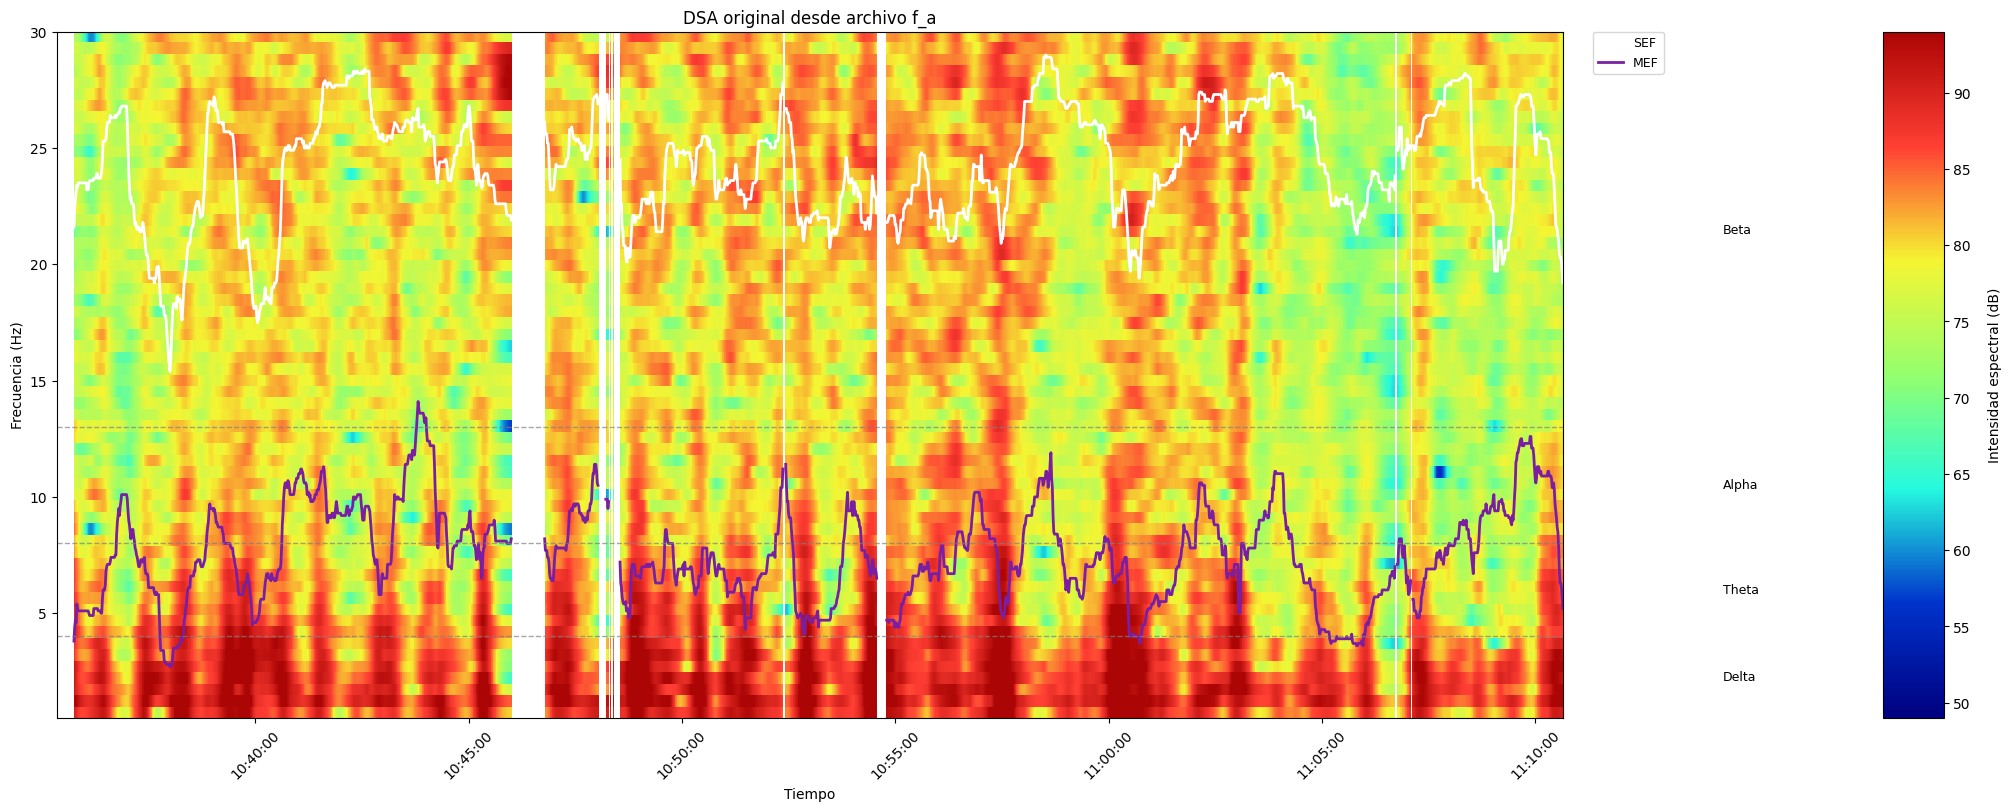

In [10]:
fig, ax, ax_band, cax = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_fa_unilat,
    frecuencias=dsa_plot_hor.columns.astype(float),
    matriz=matriz_hor,
    norm=norm_hor,
    cmap=cmap_hor,
    df_merge=df_merge_hor,
    titulo="DSA original desde archivo f_a",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_total_hor
)

### Comprobaciones

In [11]:
print("DSA f_a:", dsa_plot_hor.shape)
print("DSA EEG:", dsa_eeg.shape)

print("¿Tiempos iguales?")
print((tiempo_fa_unilat.reset_index(drop=True) == tiempo_eeg.reset_index(drop=True)).all())

print("Rango DSA EEG reconstruida:")
print(np.nanmin(dsa_eeg_plot.values), np.nanmax(dsa_eeg_plot.values))

print("Rango DSA f_a:")
print(np.nanmin(dsa_plot_hor.values), np.nanmax(dsa_plot_hor.values))

DSA f_a: (2119, 60)
DSA EEG: (2119, 60)
¿Tiempos iguales?
True
Rango DSA EEG reconstruida:
43.8952330105952 131.9917827205913
Rango DSA f_a:
55.61 103.02


## Comprobar que ambas matrices están alineadas

In [12]:
"""print("DSA f_a:", dsa_plot_hor.shape)
print("DSA EEG:", dsa_plot.shape)

print("Tiempo f_a:")
print(tiempo_fa_unilat.head())
print(tiempo_fa_unilat.tail())

print("Tiempo EEG:")
print(tiempo_eeg.head())
print(tiempo_eeg.tail())"""

'print("DSA f_a:", dsa_plot_hor.shape)\nprint("DSA EEG:", dsa_plot.shape)\n\nprint("Tiempo f_a:")\nprint(tiempo_fa_unilat.head())\nprint(tiempo_fa_unilat.tail())\n\nprint("Tiempo EEG:")\nprint(tiempo_eeg.head())\nprint(tiempo_eeg.tail())'

In [13]:
print("¿Tiempos iguales?")
print((tiempo_fa_unilat.reset_index(drop=True) == tiempo_eeg.reset_index(drop=True)).all())

¿Tiempos iguales?
True


### Comparación base

In [14]:
dsa_eeg_comp, dsa_fa_comp = fun_dsa.preparar_matrices_para_comparacion(
    dsa_eeg_plot,
    dsa_plot_hor
)

dsa_eeg_z = fun_dsa.zscore_global(dsa_eeg_comp)
dsa_fa_z = fun_dsa.zscore_global(dsa_fa_comp)

metricas_base = fun_dsa.comparar_dsa_global(
    dsa_eeg_z,
    dsa_fa_z
)

metricas_base

{'n_valores_comparados': 120360,
 'MAE': np.float64(0.853449991881016),
 'RMSE': np.float64(1.0999045923442847),
 'bias_B_menos_A': np.float64(2.7297687023551872e-15),
 'Pearson': np.float64(0.3951049438699764),
 'Spearman': np.float64(0.31501497963394975)}

### Correlación por frecuencia

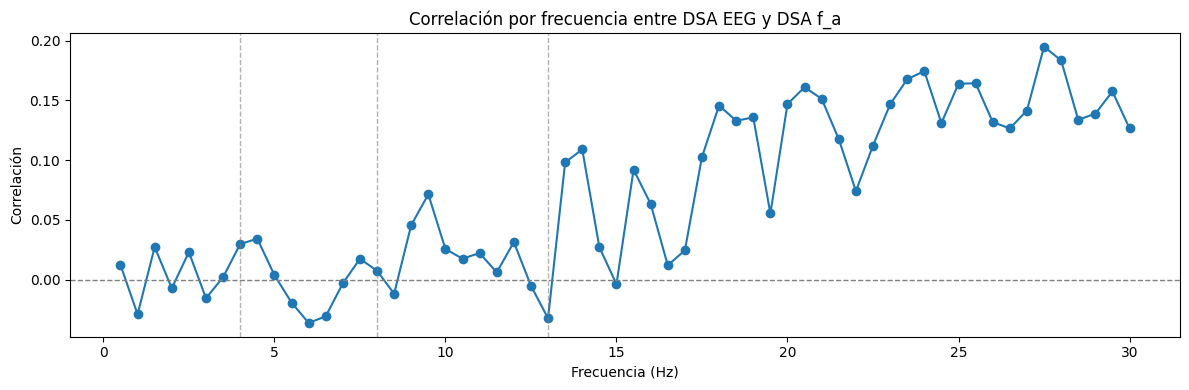

In [15]:
df_corr_freq = fun_dsa.correlacion_por_frecuencia(
    dsa_eeg_z,
    dsa_fa_z
)

plt.figure(figsize=(12, 4))

plt.plot(
    df_corr_freq["frecuencia_Hz"],
    df_corr_freq["correlacion"],
    marker="o"
)

for f in [4, 8, 13]:
    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Correlación")
plt.title("Correlación por frecuencia entre DSA EEG y DSA f_a")
plt.tight_layout()
plt.show()

### Suavizado temporal

Suavizado temporal de la DSA reconstruida desde EEG

La DSA reconstruida desde el EEG crudo viene de un cálculo directo y produce una DSA con muchos cambios rápidos. 

La DSA del f_a del BIS se ve más suave y no cambia tan bruscamente de segundo a segundo. Sugiere que el BIS podría aplicar algún tipo de promedio temporal interno antes de guardar el f_a.

In [16]:
resultados_suavizado = []

for w in [3, 5, 10, 15, 25, 30, 40]:
    dsa_eeg_suav = dsa_eeg_comp.rolling(
        window=w,
        min_periods=1,
        center=False
    ).mean()

    dsa_eeg_suav_z = fun_dsa.zscore_global(dsa_eeg_suav)

    met = fun_dsa.comparar_dsa_global(
        dsa_eeg_suav_z,
        dsa_fa_z
    )

    resultados_suavizado.append({
        "ventana_suavizado_s": w,
        "Pearson": met["Pearson"],
        "Spearman": met["Spearman"],
        "MAE": met["MAE"],
        "RMSE": met["RMSE"]
    })

df_resultados_suavizado = pd.DataFrame(resultados_suavizado)
df_resultados_suavizado.sort_values("Pearson", ascending=False)

,ventana_suavizado_s,Pearson,Spearman,MAE,RMSE
6,40,0.692555,0.688626,0.582970,0.781582
5,30,0.675518,0.659880,0.599665,0.803980
4,25,0.654236,0.626479,0.621265,0.830357
3,15,0.583326,0.518799,0.693579,0.912281
2,10,0.537728,0.457086,0.736848,0.961258
1,5,0.487217,0.399095,0.780302,1.012477
0,3,0.458697,0.370064,0.804285,1.040165


### Suavizado + shift

In [17]:
df_suav_shift = fun_dsa.probar_suavizado_y_shifts(
    dsa_eeg_comp,
    dsa_fa_comp,
    ventanas_suavizado=(5, 10, 15, 25, 30, 40, 60, 80),
    shifts=range(-60, 61)
)

df_suav_shift.sort_values("Pearson", ascending=False).head(10)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
436,25,13,0.719530,0.711431,0.557377,0.746736
435,25,12,0.719317,0.712284,0.556688,0.747106
437,25,14,0.718831,0.709242,0.559089,0.747559
434,25,11,0.718127,0.711702,0.557143,0.748767
438,25,15,0.717328,0.705770,0.561747,0.749409
555,30,11,0.717024,0.713138,0.559875,0.749870
554,30,10,0.716746,0.713673,0.559463,0.750319
556,30,12,0.716392,0.711372,0.561305,0.750640
433,25,10,0.715963,0.709722,0.558826,0.751769
553,30,9,0.715592,0.712957,0.560037,0.751956


In [18]:
df_suav_shift.sort_values("Spearman", ascending=False).head(10)

,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
554,30,10,0.716746,0.713673,0.559463,0.750319
555,30,11,0.717024,0.713138,0.559875,0.749870
553,30,9,0.715592,0.712957,0.560037,0.751956
435,25,12,0.719317,0.712284,0.556688,0.747106
434,25,11,0.718127,0.711702,0.557143,0.748767
436,25,13,0.719530,0.711431,0.557377,0.746736
556,30,12,0.716392,0.711372,0.561305,0.750640
552,30,8,0.713694,0.710981,0.561567,0.754561
433,25,10,0.715963,0.709722,0.558826,0.751769
437,25,14,0.718831,0.709242,0.559089,0.747559


### Tabla resumen final

La variante que mejor aproximó la DSA reconstruida desde EEG crudo a la DSA del archivo `f_a` fue la media de potencias de los dos canales, calculada a partir de densidad espectral de potencia y convertida posteriormente a dB. 

Tras aplicar un suavizado temporal causal de 25 s y un desplazamiento temporal de 13 s, se obtuvo una correlación de Pearson de aproximadamente 0.706 y una correlación de Spearman de aproximadamente 0.704. 

Esto sugiere que el archivo `f_a` incorpora información espectral de ambos canales, así como procesamiento temporal suavizado y un posible retardo asociado al cálculo interno del monitor BIS.

In [19]:
mejor_pearson = df_suav_shift.sort_values("Pearson", ascending=False).iloc[0]
mejor_spearman = df_suav_shift.sort_values("Spearman", ascending=False).iloc[0]

df_resumen_final = pd.DataFrame([
    {
        "criterio": "Mejor Pearson",
        "suavizado_s": mejor_pearson["suavizado_s"],
        "shift_s": mejor_pearson["shift_s"],
        "Pearson": mejor_pearson["Pearson"],
        "Spearman": mejor_pearson["Spearman"],
        "MAE": mejor_pearson["MAE"],
        "RMSE": mejor_pearson["RMSE"],
    },
    {
        "criterio": "Mejor Spearman",
        "suavizado_s": mejor_spearman["suavizado_s"],
        "shift_s": mejor_spearman["shift_s"],
        "Pearson": mejor_spearman["Pearson"],
        "Spearman": mejor_spearman["Spearman"],
        "MAE": mejor_spearman["MAE"],
        "RMSE": mejor_spearman["RMSE"],
    }
])

df_resumen_final

,criterio,suavizado_s,shift_s,Pearson,Spearman,MAE,RMSE
0,Mejor Pearson,25.0,13.0,0.719530,0.711431,0.557377,0.746736
1,Mejor Spearman,30.0,10.0,0.716746,0.713673,0.559463,0.750319


## DSA Optimizada

In [20]:
# suavizado: coges la DSA reconstruida desde el EEG y a cada fila temporal le aplicas una media móvil causal de 25 segundos
# cada instante ya no depende solo de ese segundo, sino del promedio de los 25 segundos anteriores y el actual
suavizado_final = 25

shift_final = 13

# Suavizado causal de la DSA reconstruida
dsa_eeg_suav = dsa_eeg_comp.rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()


# Aplicar shift solo para comparación visual con f_a: reconstruida suavizada le quitas las últimas 13 filas,
    # y a la del .f_a le quitas las primeras 13
    
# el shift no cambia los colores por sí mismo
# lo que cambia con el shift es qué parte del tiempo estás comparando con qué otra parte
dsa_eeg_opt = dsa_eeg_suav.iloc[:-shift_final].reset_index(drop=True)
dsa_fa_opt = dsa_fa_comp.iloc[shift_final:].reset_index(drop=True)

tiempo_opt = tiempo_eeg.iloc[shift_final:].reset_index(drop=True)


# Igualar longitudes
n = min(len(dsa_eeg_opt), len(dsa_fa_opt), len(tiempo_opt))

dsa_eeg_opt = dsa_eeg_opt.iloc[:n]
dsa_fa_opt = dsa_fa_opt.iloc[:n]
tiempo_opt = tiempo_opt.iloc[:n]

In [21]:
# Normalizar para comparar visualmente patrones

""" 
calcula la media de toda la matriz,
calcula la desviación típica de toda la matriz,
y convierte cada celda en:

z = (x−μ) /σ

donde:
 - x = valor original de esa celda,
 - μ = media global de esa matriz,
 - σ = desviación típica global de esa matriz.
 
 
Después del z-score:
un valor 0 significa: “esta celda está justo en la media de esa matriz”
un valor positivo significa: “esta celda está por encima de la media”
un valor negativo significa: “esta celda está por debajo de la media”


Eso quiere decir que en esa figura final:
los colores ya no representan dB reales
los colores ya no representan la escala del BIS
los colores representan intensidad relativa dentro de cada matriz: 
 - Un rojo antes podía significar: potencia espectral alta en dB
 - Un rojo ahora significa: valor bastante por encima de la media de esa misma matriz
"""


dsa_fa_z_plot = fun_dsa.zscore_global(dsa_fa_opt)
dsa_eeg_z_plot = fun_dsa.zscore_global(dsa_eeg_comp.iloc[shift_final:].reset_index(drop=True).iloc[:n])
dsa_eeg_opt_z_plot = fun_dsa.zscore_global(dsa_eeg_opt)

cmap = fun_dsa.crear_cmap_bis()

In [22]:
def plot_comparacion_tres_dsa(
    tiempo,
    frecuencias,
    dsa_fa,
    dsa_eeg,
    dsa_eeg_opt,
    titulo_1="DSA original f_a",
    titulo_2="DSA reconstruida desde EEG",
    titulo_3="DSA reconstruida suavizada + shift",
    cmap=cmap
):
    """
    Dibuja tres DSA una debajo de otra para comparación visual.
    Las matrices deben tener filas = tiempo y columnas = frecuencia.
    """

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(20, 12),
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    matrices = [
        dsa_fa.to_numpy(dtype=float),
        dsa_eeg.to_numpy(dtype=float),
        dsa_eeg_opt.to_numpy(dtype=float)
    ]

    titulos = [titulo_1, titulo_2, titulo_3]

    # Escala común para las tres matrices normalizadas
    todos_valores = np.concatenate([
        m[np.isfinite(m)] for m in matrices
    ])

    vmin = np.nanpercentile(todos_valores, 2)
    vmax = np.nanpercentile(todos_valores, 98)

    x0 = mdates.date2num(tiempo.iloc[0])
    x1 = mdates.date2num(tiempo.iloc[-1])

    y0 = np.min(frecuencias)
    y1 = np.max(frecuencias)

    for ax, matriz, titulo in zip(axes, matrices, titulos):
        im = ax.imshow(
            matriz.T,
            aspect="auto",
            origin="lower",
            extent=[x0, x1, y0, y1],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest"
        )

        ax.set_title(titulo)
        ax.set_ylabel("Frecuencia (Hz)")
        ax.set_ylim(y0, y1)

        for f in [4, 8, 13]:
            ax.axhline(
                f,
                color="gray",
                linestyle="--",
                linewidth=1,
                alpha=0.7
            )

    axes[-1].set_xlabel("Tiempo")

    axes[-1].xaxis_date()
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    plt.setp(axes[-1].get_xticklabels(), rotation=45)

    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation="vertical",
        fraction=0.025,
        pad=0.02
    )
    cbar.set_label("Intensidad normalizada (z-score)")

    plt.show()

    return fig, axes

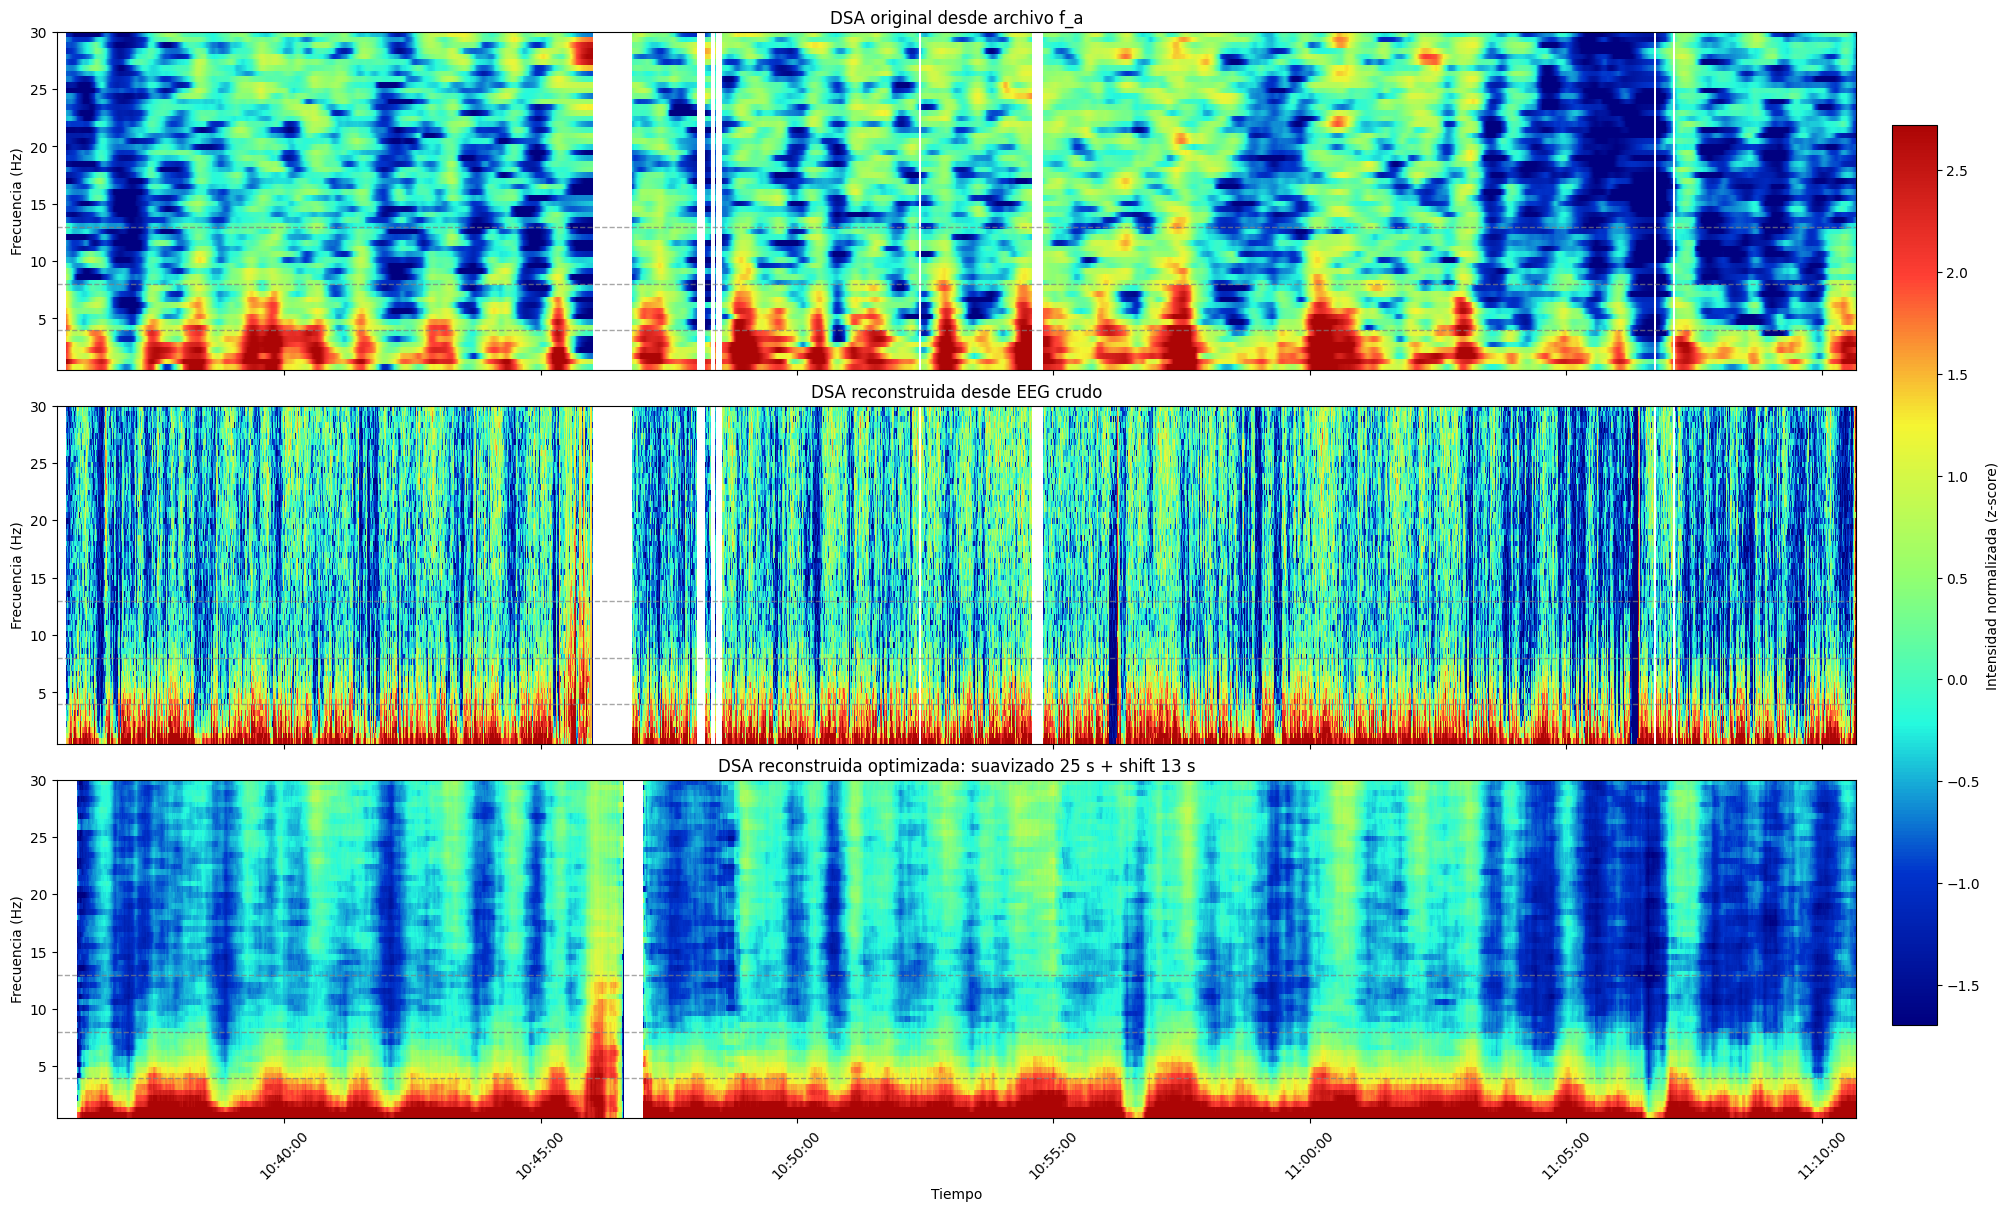

In [23]:
fig, axes = plot_comparacion_tres_dsa(
    tiempo=tiempo_opt,
    frecuencias=frecuencias,
    dsa_fa=dsa_fa_z_plot,
    dsa_eeg=dsa_eeg_z_plot,
    dsa_eeg_opt=dsa_eeg_opt_z_plot,
    titulo_1="DSA original desde archivo f_a",
    titulo_2="DSA reconstruida desde EEG crudo",
    titulo_3="DSA reconstruida optimizada: suavizado 25 s + shift 13 s"
)

## Comparación entre la DSA reconstruida desde EEG crudo y la DSA exportada por el BIS

El objetivo de este bloque es evaluar de forma objetiva la similitud entre la matriz tiempo-frecuencia obtenida desde el EEG crudo y la matriz exportada por el monitor BIS.

Se ha desarrollado un sistema comparador para evaluar la similitud entre la DSA reconstruida desde el EEG crudo y la DSA contenida en el archivo .f_a.

Este sistema compara ambas matrices tanto visual como cuantitativamente. 
Para ello:
 - Las matrices se alinean temporal y frecuencialmente
 - Se eliminan los tramos no válidos mediante una máscara común
 - Se nrmalizan mediante el z - score para compensar diferencias de escala
 - Se calculan métricas de similitud: Correlación de Pearson, Correlación de Spearman, MAE y RMSE.
 
Además, el sistema ha permitido evaluar variantes de procesamiento, como el suavizado temporal, para determinar qué configuración reproduce mejor la matriz construida a partir del archivo .f_a.

------------------------------------------------------------------------------------------------
### Cambio de los colores en la figura final y funcionamiento del z-score

En la figura comparativa final, los colores no representan los valores absolutos originales de cada matriz, sino valores normalizados mediante el z-score. 

Esta normalización transforma cada celda según su desviación respecto a la media global de su propia matriz. Por tanto, los colores indican si una región presenta una intensidad relativamente alta o baja dentro de cada DSA. 

Al emplear una escala común para las tres matrices normalizadas, la figura permite comparar patrones relativos, aunque el aspecto cromático difiera del observado en las tres representaciones individuales.

$$
Z(t,f)=\frac{D(t,f)-\mu_D}{\sigma_D}
$$

Donde: 
 - D(t,f) es el valor de la DSA en el instante \(t\) 
 - la frecuencia \(f\)
 - $\mu_D$ es la media global de la matriz 
 - $\sigma_D$ su desviación típica.

### Suavizado temporal

La DSA reconstruida desde el EEG crudo presenta variaciones rápidas segundo a segundo, al estar calculada mediante ventanas cortas de 2 segundos con un avance de 1 segundo. Sin embargo, la DSA del archivo f_a mostraba una evolución temporal más suave.

Por ello, se evaluó un suavizado temporal causal mediante media móvil. 
Este suavizado promedia las filas anteriores de cada frecuencia sin mezclar bandas frecuenciales, reduciendo fluctuaciones rápidas y aproximando la estabilidad temporal observada en el archivo exportado por el BIS.

$$
\tilde{D}(t,f)=\frac{1}{W}\sum_{i=0}^{W-1}D(t-i,f)
$$

donde \(W\) es el número de segundos usados en la ventana de suavizado. Si min_periods=1, el inicio se promedia con las muestras disponibles.

#### Afectación del suavizado temporal a los tramos no válidos

Las bandas blancas tepresentan tramos no válidos o pérdida de información. Al aplicar un suavizado temporal mediante la media móvil, algunos valores NaN quedaban reemplazados por promedios de valores válidos cercanos.

Esto provoca que ciertas bandas blancas desaparezcan en la DSA optimizada, aunque sigan correspondiendo a tramos de señal no válida. Para evitarlo, se volvió a aplicar la máscara de pérdida de información después del suavizado y del desplazamiento temporal. De este modo, las zonas no válidas permanecen blancas en todas las matrices comparadas.

Las bandas blancas de la DSA optimizada no tienen por qué coincidir exactamente con las de la DSA reconstruida sin desplazar, porque la versión optimizada ha sido desplazada temporalmente. Lo importante es que la máscara de validez se aplique de forma consistente con el mismo recorte y desplazamiento que se usa para comparar las matrices.


### Shift temporal

Aunque ambas matrices estaban alineadas por marca temporal, el cálculo interno del monitor puede introducir un retardo efectivo debido al uso de ventanas temporales, promediado o procesamiento acumulativo.

Por ello se evaluaron desplazamientos temporales entre matrices. El desplazamiento no se aplicó para modificar la señal reconstruida original, sino para estimar qué desfase proporcionaba la mayor correspondencia con la matriz f_a.

La mejor similitud se obtuvo con un suavizado causal de 25 segundos y un desplazamiento de 13 segundos, lo que sugiere que la DSA del f_a podría incorporar procesamiento temporal acumulado y cierto retardo respecto a la estimación espectral instantánea.


### Media de potencia de los dos canales

La señal r2a contiene dos canales EEG. Se evaluaron reconstrucciones usando canal 1, canal 2 y una combinación de ambos.

La mejor similitud se obtuvo al promediar las densidades espectrales de potencia de ambos canales en escala lineal y convertir posteriormente a dB.

Esta estrategia es preferible a promediar directamente los dB, ya que la escala logarítmica no es lineal. El resultado sugiere que la DSA del f_a podría incorporar información espectral procedente de ambos canales.

$$
P_{\text{media}}(t,f)=\frac{P_1(t,f)+P_2(t,f)}{2}
$$

$$
D_{\text{media}}(t,f)=10\log_{10}\left(P_{\text{media}}(t,f)\right)
$$


### Métricas

La correlación de Pearson mide la similitud lineal entre los valores normalizados de ambas matrices.

La correlación de Spearman mide si el orden relativo de intensidades se conserva entre matrices, aunque la relación no sea estrictamente lineal.

El MAE y el RMSE cuantifican el error medio entre las matrices normalizadas. Estas métricas se calcularon únicamente sobre celdas válidas en ambas matrices.


### Figura final de las 3 DSA

La figura comparativa final permite observar de forma conjunta la DSA original extraída del archivo f_a, la DSA reconstruida directamente desde el EEG crudo y la versión optimizada de dicha reconstrucción.

Esta última incorpora el suavizado temporal y el desplazamiento que proporcionaron la mayor similitud cuantitativa con la DSA del f_a.

La finalidad de esta figura no es sustituir la DSA reconstruida original, sino mostrar visualmente cómo las operaciones de optimización acercan su estructura tiempo-fracuencia a la matriz de referencia.


#### DSA reconstruida

Es el resultado directo de la aplicación de la siguiente metodología:

Se parte del EEG crudo
 1. Se hace una lectura binaria
 2. Se escalan los valores a microvoltios
 3. Se calcula la PSD (power spectral density) con Welch
 4. Se calcula la media de potencias de los canales 1 y 2
 5. Se realiza la conversión a decibelios
 6. Se construye la matriz tiempo-frecuencia y se dibuja el plot
 

#### DSA optimizada

Es una versión empleada para la comparación:

Se parte de la DSA reconstruida
 1. Se aplica un suavizado temporal
 2. Se aplica un desplazamiento temporal
 3. Se le hace la comparación con la matriz del f_a.
 

La DSA reconstruida directamente desde el EEg crudo representa la salida del método espectral implementado.

La DSA optimizada, en cambio, no se interpreta como una nueva señal original, sino como una transformación auxiliar destinada a evaluar hasta qué punto la reconstrucción puede aproximarse a la DSA exportada por el BIS cuando se incorporan operaciones compatibles con un posible procesamiento interno del monitor, como suavizado temporal y retardo de cálculo.

-----------------------------------------------------------------------------------------------

El sistema es un comparador porque no solo genera una imagen:
- alinea las matrices;
- aplica una máscara de validez común;
- normaliza las escalas;
- calcula correlaciones y errores;
- permite probar variantes de reconstrucción;
- identifica la configuración que maximiza la similitud;
- muestra una comparación visual final.

### Shift solo


In [24]:

""" 
Se evaluó también el desplazamiento temporal aislado, aunque la mejora fue menor que al combinarlo con suavizado temporal.
"""

def probar_shifts_dsa(dsa_eeg, dsa_fa, shifts=range(-60, 61)):
    resultados = []

    for shift in shifts:
        if shift < 0:
            A = dsa_eeg.iloc[-shift:].reset_index(drop=True)
            B = dsa_fa.iloc[:len(A)].reset_index(drop=True)
        elif shift > 0:
            A = dsa_eeg.iloc[:-shift].reset_index(drop=True)
            B = dsa_fa.iloc[shift:].reset_index(drop=True)
        else:
            A = dsa_eeg.reset_index(drop=True)
            B = dsa_fa.reset_index(drop=True)

        n = min(len(A), len(B))
        A = A.iloc[:n]
        B = B.iloc[:n]

        A_z = fun_dsa.zscore_global(A)
        B_z = fun_dsa.zscore_global(B)

        met = fun_dsa.comparar_dsa_global(A_z, B_z)

        resultados.append({
            "shift_s": shift,
            "Pearson": met["Pearson"],
            "Spearman": met["Spearman"],
            "MAE": met["MAE"],
            "RMSE": met["RMSE"]
        })

    return pd.DataFrame(resultados)

df_shifts = probar_shifts_dsa(
    dsa_eeg_comp,
    dsa_fa_comp,
    shifts=range(-60, 61)
)

df_shifts.sort_values("Pearson", ascending=False).head(10)

,shift_s,Pearson,Spearman,MAE,RMSE
84,24,0.533969,0.467855,0.742187,0.959779
85,25,0.533695,0.466447,0.743023,0.960099
83,23,0.533245,0.468100,0.742023,0.960638
86,26,0.532856,0.464743,0.744166,0.960893
82,22,0.532328,0.468025,0.742104,0.961658
80,20,0.531391,0.467655,0.743836,0.964783
87,27,0.530644,0.461508,0.746565,0.963458
81,21,0.530338,0.467383,0.743297,0.964710
79,19,0.530049,0.466285,0.745548,0.966967
88,28,0.527839,0.457738,0.749219,0.966235


In [75]:
suavizado_final = 25
shift_final = 13

# suavizado
dsa_eeg_suav = dsa_eeg_comp.rolling(
    window=suavizado_final,
    min_periods=1,
    center=False
).mean()


dsa_eeg_opt = dsa_eeg_suav.copy()
tiempo_opt = tiempo_eeg.copy()
df_merge_opt = df_merge_plot.copy()
mask_total_opt = mask_total.copy()


dsa_eeg_opt = dsa_eeg_opt.copy()
dsa_eeg_opt.loc[mask_total_opt.values, :] = np.nan

vals_comunes = np.concatenate([
    dsa_plot_hor.to_numpy(dtype=float)[np.isfinite(dsa_plot_hor.to_numpy(dtype=float))],
    dsa_eeg_plot.to_numpy(dtype=float)[np.isfinite(dsa_eeg_plot.to_numpy(dtype=float))],
    dsa_eeg_opt.to_numpy(dtype=float)[np.isfinite(dsa_eeg_opt.to_numpy(dtype=float))]
])

vmin_comun = np.nanpercentile(vals_comunes, 2)
vmax_comun = np.nanpercentile(vals_comunes, 99.5)

matriz_opt, _, _, norm_opt, cmap_opt = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_opt,
    vmin=vmin_comun,
    vmax=vmax_comun,
    gamma=0.4
)

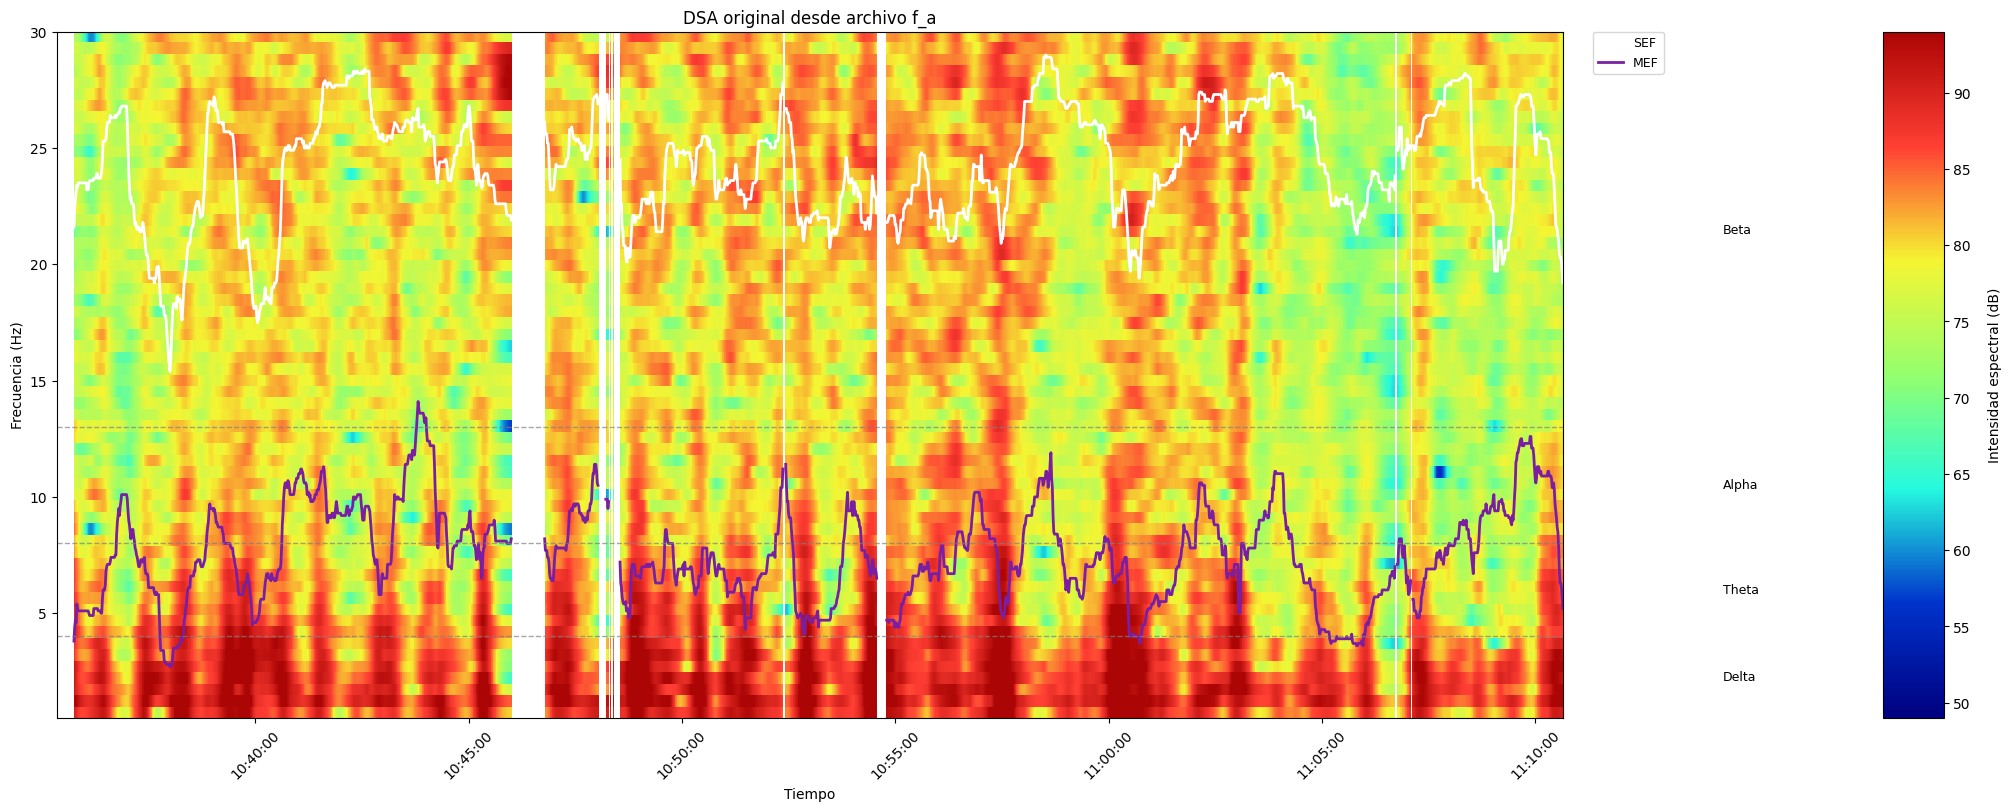

In [56]:
fig_fa, ax_fa, ax_band_fa, cax_fa = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_fa_unilat,
    frecuencias=dsa_plot_hor.columns.astype(float),
    matriz=matriz_hor,
    norm=norm_hor,
    cmap=cmap_hor,
    df_merge=df_merge_hor,
    titulo="DSA original desde archivo f_a",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_total_hor
)

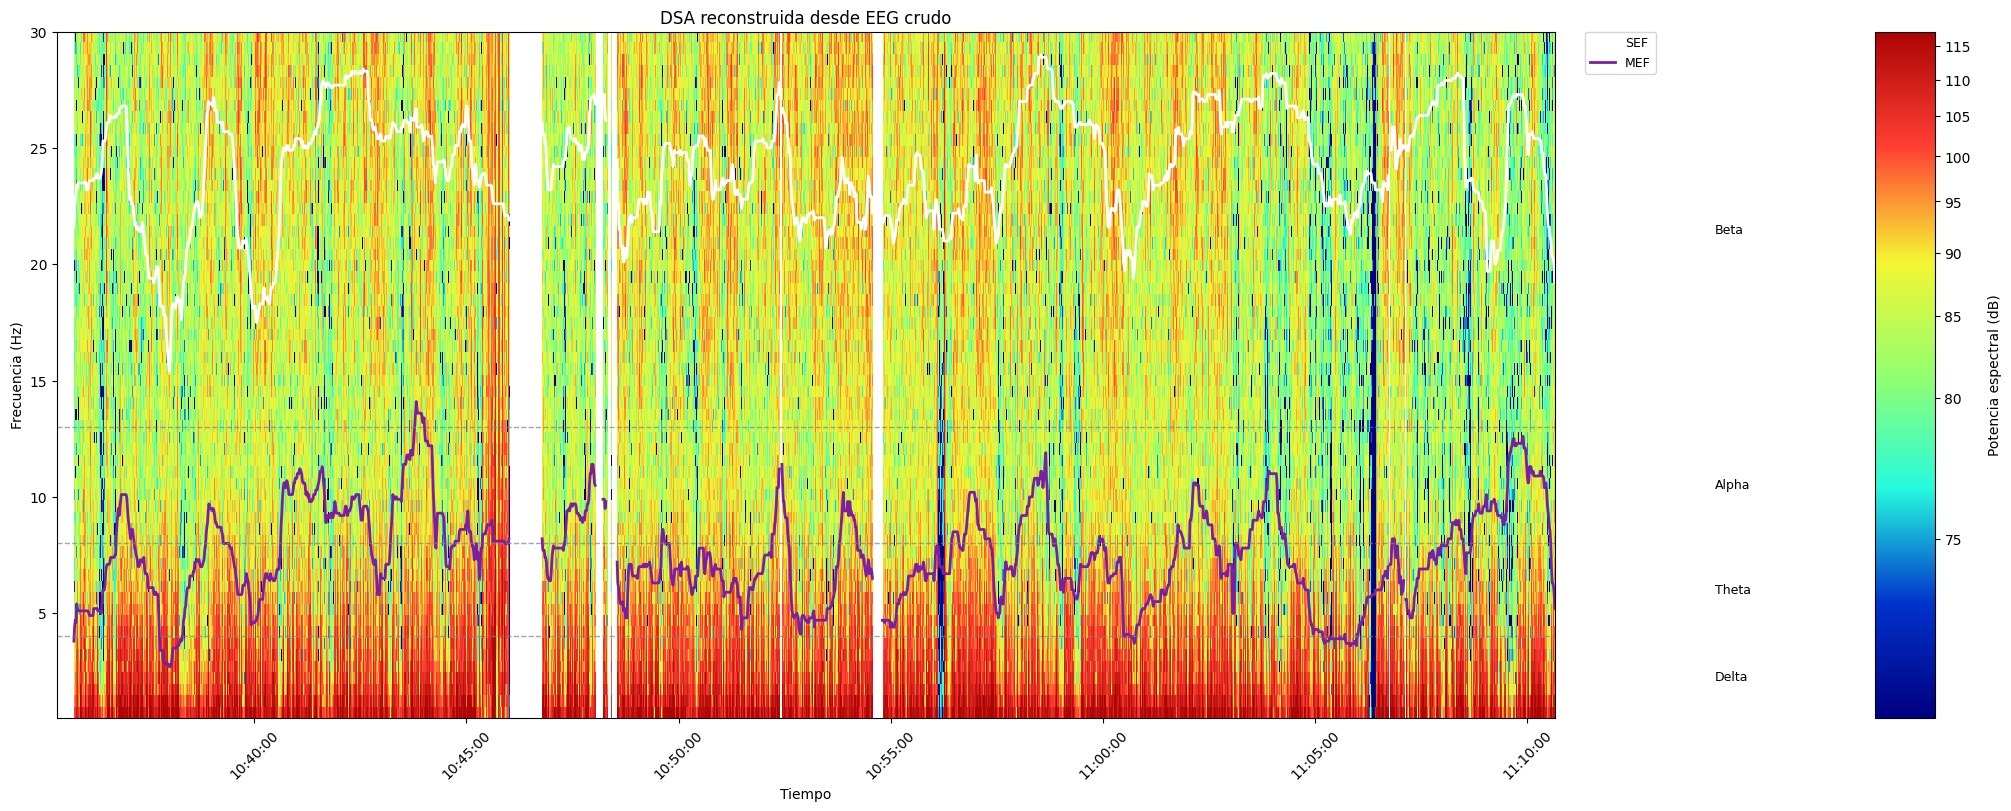

In [57]:
fig_eeg, ax_eeg, ax_band_eeg, cax_eeg = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg,
    frecuencias=frecuencias,
    matriz=matriz_eeg,
    norm=norm_eeg,
    cmap=cmap_eeg,
    df_merge=df_merge_plot,
    titulo="DSA reconstruida desde EEG crudo",
    mask_total=mask_total
)

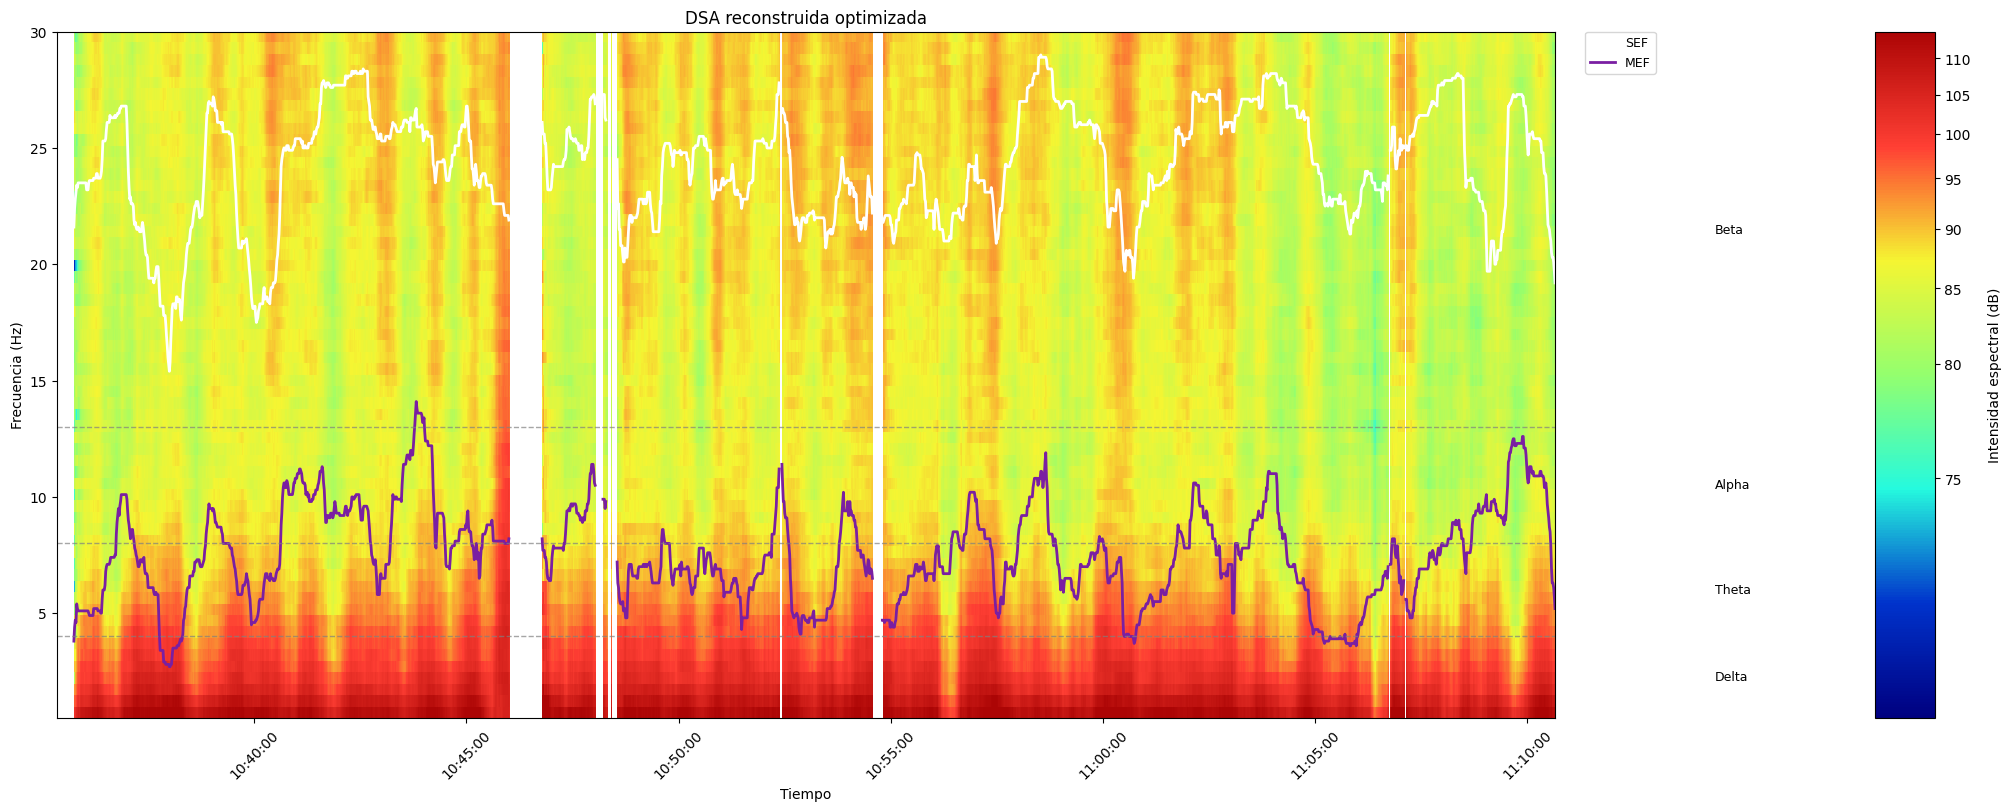

In [76]:
fig_opt, ax_opt, ax_band_opt, cax_opt = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_opt,
    frecuencias=frecuencias,
    matriz=matriz_opt,
    norm=norm_opt,
    cmap=cmap_opt,
    df_merge=df_merge_opt,
    titulo="DSA reconstruida optimizada",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_total_opt
)

## Figura para validación metodológica



In [77]:
dsa_eeg_opt_desfase = dsa_eeg_suav.iloc[:-shift_final].reset_index(drop=True)
tiempo_opt_desfase = tiempo_eeg.iloc[shift_final:].reset_index(drop=True)
df_merge_opt_desfase = df_merge_plot.iloc[shift_final:].reset_index(drop=True)
mask_total_opt_desfase = mask_total.iloc[shift_final:].reset_index(drop=True)

dsa_eeg_opt_desfase = dsa_eeg_opt_desfase.copy()
dsa_eeg_opt_desfase.loc[mask_total_opt_desfase.values, :] = np.nan

vmin_comun = np.nanpercentile(vals_comunes, 2)
vmax_comun = np.nanpercentile(vals_comunes, 99.5)

matriz_opt_desfase, _, _, norm_opt_desfase, cmap_opt_desfase = fun_dsa.preparar_escala_color_dsa(
    dsa_eeg_opt_desfase,
    vmin=vmin_comun,
    vmax=vmax_comun,
    gamma=0.4
)

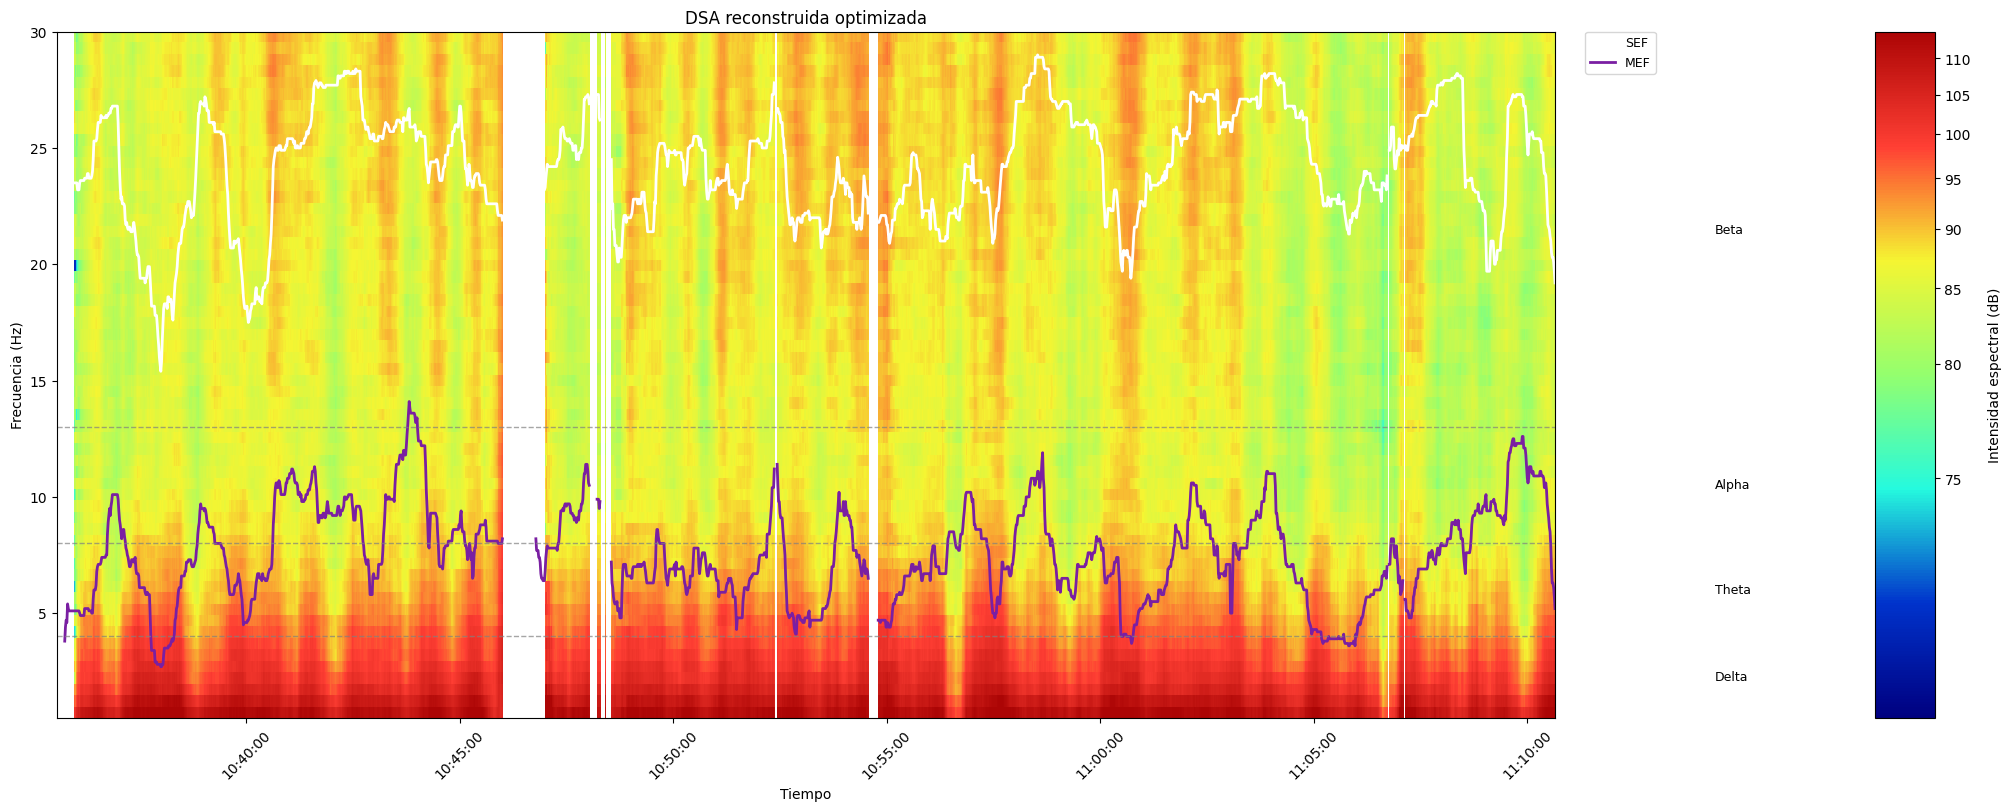

In [78]:
fig_opt_desfase, ax_opt_desfase, ax_band_opt_desfase, cax_opt_desfase = fun_plot.plot_dsa_con_sef_mef(
    tiempo=tiempo_opt_desfase,
    frecuencias=frecuencias,
    matriz=matriz_opt_desfase,
    norm=norm_opt_desfase,
    cmap=cmap_opt_desfase,
    df_merge=df_merge_opt_desfase,
    titulo="DSA reconstruida optimizada",
    etiqueta_colorbar="Intensidad espectral (dB)",
    mask_total=mask_total_opt_desfase
)

# COMPARACIÓN FINAL